# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
# !gdown 14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw -O '../data/checker-submits.csv'

In [3]:
df = pd.read_csv('../data/checker-submits.csv')
df.timestamp = pd.to_datetime(df.timestamp)
df['hour'] = df.timestamp.dt.hour
df['dayofweek'] = df.timestamp.dt.weekday
df = df.drop(columns='timestamp')
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   uid        1686 non-null   object
 1   labname    1686 non-null   object
 2   numTrials  1686 non-null   int64 
 3   hour       1686 non-null   int32 
 4   dayofweek  1686 non-null   int32 
dtypes: int32(2), int64(1), object(2)
memory usage: 52.8+ KB


In [5]:
encoder = OneHotEncoder(sparse_output=False)
enc_cols = encoder.fit_transform(df[["uid", "labname"]])
enc = pd.DataFrame(enc_cols, columns=encoder.get_feature_names_out(["uid", "labname"]))
enc

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
df = pd.concat([df, enc], axis=1)
df = df.drop(columns=['uid', 'labname'])
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,9,20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,6,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,7,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,8,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [7]:
scaler = StandardScaler()

scaled = scaler.fit_transform(df[['numTrials', 'hour']])

df_scaled = pd.DataFrame(scaled, columns=['numTrials', 'hour'])
df_scaled

,numTrials,hour
0,-0.788667,-2.562352
1,-0.756764,-2.562352
2,-0.724861,-2.562352
3,-0.692958,-2.562352
4,-0.661055,-2.562352
...,...,...
1681,-0.533442,0.945382
1682,-0.629151,0.945382
1683,-0.597248,0.945382
1684,-0.565345,0.945382


In [8]:
df = df.drop(columns=['numTrials', 'hour'])
df = pd.concat([df_scaled, df], axis=1)
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
df.to_csv("../data/dayofweek.csv", index=False)

In [10]:
y = df.dayofweek
(y == y.mode()[0]).mean()

np.float64(0.23487544483985764)

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [11]:
X = df.drop(columns=["dayofweek"])
y = df["dayofweek"]

In [12]:
model = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
model.fit(X, y)
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
acc

/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


0.6215895610913404

In [13]:
def top_features(model, feature_names, n):

    imp = np.mean(np.abs(np.atleast_2d(model.coef_)), axis=0)

    n = min(n, len(imp))
    idx = np.argsort(imp)[-n:]

    plt.barh(np.array(feature_names)[idx], imp[idx])
    plt.tight_layout()
    plt.show()

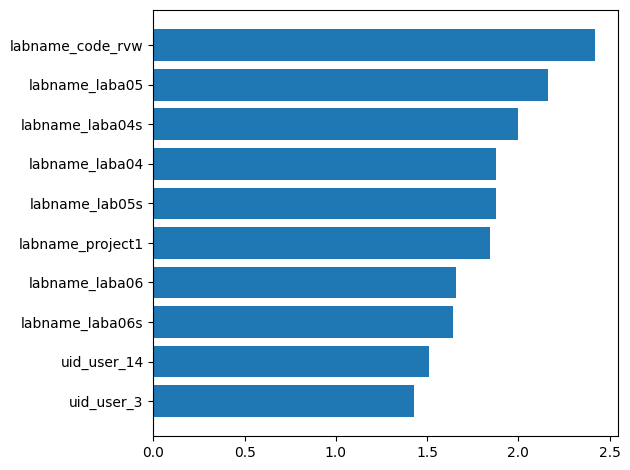

In [14]:
top_features(model, X.columns, 10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [15]:
model_svc = SVC(random_state=21, probability=True, kernel='poly')
model_svc.fit(X, y)

y_pred_svc = model_svc.predict(X)
acc = accuracy_score(y, y_pred_svc)
acc

0.8594306049822064

In [16]:
model_svc = SVC(random_state=21, probability=True, kernel='rbf')
model_svc.fit(X, y)

y_pred_svc = model_svc.predict(X)
acc = accuracy_score(y, y_pred_svc)
acc

0.8558718861209964

In [17]:
model_svc = SVC(random_state=21, probability=True, kernel='sigmoid')
model_svc.fit(X, y)

y_pred_svc = model_svc.predict(X)
acc = accuracy_score(y, y_pred_svc)
acc

0.3997627520759193

In [18]:
model_svc = OneVsRestClassifier(SVC(random_state=21, probability=True, kernel='linear'))
model_svc.fit(X, y)

y_pred_svc = model_svc.predict(X)
acc = accuracy_score(y, y_pred_svc)
acc

0.6115065243179122

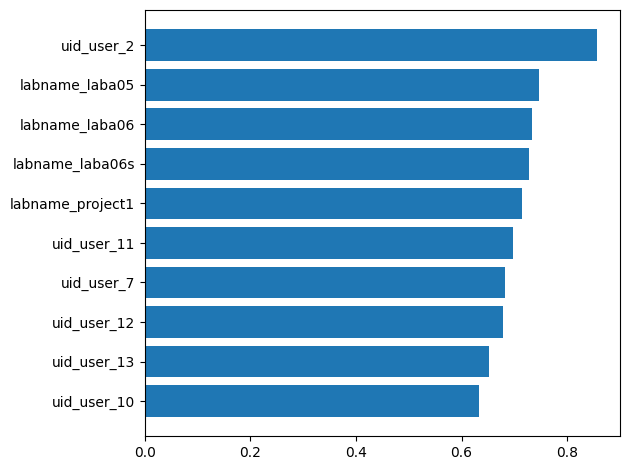

In [19]:
model_svc.coef_ = np.mean(np.abs(np.vstack([est.coef_ for est in model_svc.estimators_])),
                          axis=0, keepdims=True)
top_features(model_svc, X.columns, 10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [20]:
model_destr = DecisionTreeClassifier(random_state=42, max_depth=8)
model_destr.fit(X, y)

des_pred = model_destr.predict(X)
acc = accuracy_score(y, des_pred)
acc


0.7502965599051008

In [21]:
model_destr = DecisionTreeClassifier(random_state=42, max_depth=4)
model_destr.fit(X, y)

des_pred = model_destr.predict(X)
acc = accuracy_score(y, des_pred)
acc


0.5516014234875445

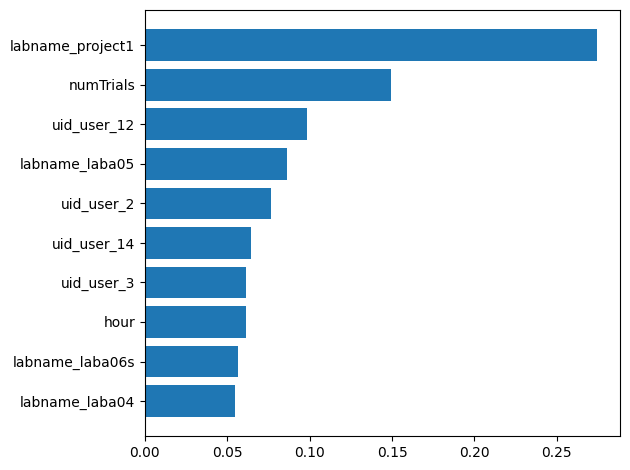

In [22]:
model_destr.coef_ = model_destr.feature_importances_.reshape(1, -1)
top_features(model_destr, X.columns, 10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [23]:
model_rnf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_rnf.fit(X, y)

des_pred = model_rnf.predict(X)
acc = accuracy_score(y, des_pred)
acc


1.0

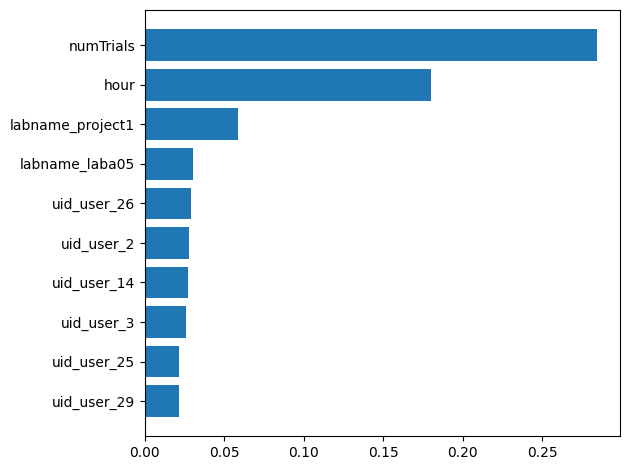

In [24]:
model_rnf.coef_ = model_rnf.feature_importances_.reshape(1, -1)
top_features(model_rnf, X.columns, 10)

In [25]:
model_rnf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=21)
model_rnf.fit(X, y)

des_pred = model_rnf.predict(X)
acc = accuracy_score(y, des_pred)
acc


0.9780545670225386

In [31]:
model_rnf = RandomForestClassifier(n_estimators=75, max_depth=25, random_state=21)
model_rnf.fit(X, y)

des_pred = model_rnf.predict(X)
acc = accuracy_score(y, des_pred)
acc


0.9994068801897983

In [32]:
model_rnf = RandomForestClassifier(n_estimators=75, max_depth=15, random_state=21)
model_rnf.fit(X, y)

des_pred = model_rnf.predict(X)
acc = accuracy_score(y, des_pred)
acc


0.9792408066429419